# Activity and actograms for best week

This notebook characterises activity patterns across the cohort during the best week selected in notebook 04:

- Binned activity (cumulative distance per time bin) over the full week
- Combined activity heatmap across all individuals
- Individual actograms (daily activity patterns stacked vertically)
- Combined stacked actogram for the full cohort
- Average daily activity profile (mean across days per individual)

The resulting `activity` time series and `actogram` array are saved as `activity_best_week.nc` for use in notebook 07.

In [1]:
# Autoreload imports
%load_ext autoreload
%autoreload 2

In [2]:
from pathlib import Path

import numpy as np
import pandas as pd
import seaborn as sns
import xarray as xr
from matplotlib import pyplot as plt
from tqdm import tqdm

from smart_kages_movement.plots import (
    plot_activity_heatmap,
    plot_actogram,
    plot_actogram_cohort,
    plot_mean_daily_activity_profile,
)

## Configuration
Define some global variables for this notebook.

In [3]:
PIXELS_PER_CM = 10  # pixels per centimeter (need to double-check this value)
DARK_PERIOD = ("09:30", "20:30")  # dark period in hh:mm format
TIME_BIN_MINUTES = 5  # time bin size in minutes
VALID_FRACTION_THRESHOLD = 0.7  # min fraction of valid frames per bin for activity

Configure seaborn plots style and xarray display options for better readability.

In [4]:
sns.set_context("notebook")
sns.set_style("ticks")

xr.set_options(display_expand_attrs=False)
xr.set_options(display_expand_data=False);

Define paths to the `movement_analysis` directory and relevant files.

In [5]:
project_dir = Path("/mnt/Data/Smart-Kages/2024-04-Apr-May-Downs")
analysis_dir = project_dir / "movement_analysis"
assert analysis_dir.exists(), f"Path does not exist: {analysis_dir}"

best_week_dir = analysis_dir / "bodycenter_best_week"
best_week_file = best_week_dir / "bodycenter_best_week.nc"
assert best_week_file.exists(), f"Path does not exist: {best_week_file}"

Define mapping between kage IDs and groups (in this case genotype) for later use.
Feel free to edit the `GROUPS` dictionary and `GROUPS_VAR` to match your specific kage IDs and group labels.

In [6]:
# Define group labels per kage ()
GROUPS = {
    "X": [3, 5, 6, 7, 9, 11, 12, 13, 14, 15, 22, 23, 26, 28, 30],
    "P": [1, 2, 4, 8, 10, 16, 17, 18, 19, 20, 21, 24, 25, 27, 29, 31, 32, 33],
}
GROUPS_VAR = "genotype"  # name of the group variable to use in plots

# Map kage IDs to groups
kage_to_group = {f"kage{id}": group for group, ids in GROUPS.items() for id in ids}
print(kage_to_group)

{'kage3': 'X', 'kage5': 'X', 'kage6': 'X', 'kage7': 'X', 'kage9': 'X', 'kage11': 'X', 'kage12': 'X', 'kage13': 'X', 'kage14': 'X', 'kage15': 'X', 'kage22': 'X', 'kage23': 'X', 'kage26': 'X', 'kage28': 'X', 'kage30': 'X', 'kage1': 'P', 'kage2': 'P', 'kage4': 'P', 'kage8': 'P', 'kage10': 'P', 'kage16': 'P', 'kage17': 'P', 'kage18': 'P', 'kage19': 'P', 'kage20': 'P', 'kage21': 'P', 'kage24': 'P', 'kage25': 'P', 'kage27': 'P', 'kage29': 'P', 'kage31': 'P', 'kage32': 'P', 'kage33': 'P'}


Derive time-binning parameters from the configuration.

In [7]:
time_bin_delta = pd.Timedelta(minutes=TIME_BIN_MINUTES)
n_daily_bins = int(24 * 60 / TIME_BIN_MINUTES)
bin_centers = np.arange(TIME_BIN_MINUTES / 2, 24 * 60, TIME_BIN_MINUTES)

## Load speed data
The `speed` variable was computed in notebook 05 and appended to the dataset.

In [8]:
ds = xr.open_dataset(best_week_file)

speed = ds.speed.squeeze("keypoints")

Assign 'genotype' as an extra coordinate to the 'individuals' dimension.

This will allow us to later group and compare activity patterns by genotype.

In [9]:
group_labels = [
    kage_to_group.get(kage_id, "Unknown") for kage_id in ds.individuals.values
]

speed = speed.assign_coords(**{GROUPS_VAR: ("individuals", group_labels)})
speed

<xarray.DataArray 'speed' (time: 1209601, individuals: 26)> Size: 252MB
[31449626 values with dtype=float64]
Coordinates:
  * time             (time) datetime64[ns] 10MB 1970-01-01 ... 1970-01-08
    seconds_elapsed  (time) float64 10MB ...
  * individuals      (individuals) <U6 624B 'kage1' 'kage2' ... 'kage33'
    genotype         (individuals) <U1 104B 'P' 'P' 'X' 'P' ... 'X' 'P' 'P' 'P'
    keypoints        <U10 40B 'bodycenter'
Attributes: (1)

## Compute binned activity

As a measure of **activity** we'll use the **cumulative distance traversed by the mouse's body centroid in a given time bin** (with duration `TIME_BIN_MINUTES`). Since we have already computed the speed (cm/sec), we can multiply that by the time bin duration in seconds to get the distance (cm). Then we sum the distance traversed in each time bin to get the activity level.

Because the speed data contains NaN values (from missing or low-confidence frames), we track the fraction of valid data in each time bin. Bins where less than a given `VALID_FRACTION_THRESHOLD` of valid frames are masked out to avoid underestimating activity.
In the plots that follow, these bins will appear as transparent white areas.

In [10]:
time_diff = speed.coords["seconds_elapsed"].diff(dim="time")
distance = speed * time_diff

# Track the fraction of valid data per bin
valid_fraction = distance.notnull().resample(time=time_bin_delta).mean()

# Compute activity and mask bins below the valid fraction threshold
activity = distance.resample(time=time_bin_delta).sum()
activity = activity.where(valid_fraction > VALID_FRACTION_THRESHOLD)

# Shift time coordinates from bin start to bin center
activity = activity.assign_coords(time=activity.time + time_bin_delta / 2)

# Store some metadata for later reference
activity.attrs["units"] = f"cm/{TIME_BIN_MINUTES}min"
activity.attrs["name"] = "activity"
activity.attrs["long_name"] = f"cumulative distance [cm/{TIME_BIN_MINUTES}min]"
activity.attrs["time_bin_minutes"] = TIME_BIN_MINUTES
activity.attrs["valid_fraction_threshold"] = VALID_FRACTION_THRESHOLD

# Show the activity data array
activity

<xarray.DataArray (time: 2017, individuals: 26)> Size: 420kB
12.58 10.29 88.69 8.153 13.17 158.8 nan 20.7 ... nan nan nan nan nan nan nan nan
Coordinates:
  * time         (time) datetime64[ns] 16kB 1970-01-01T00:02:30 ... 1970-01-0...
  * individuals  (individuals) <U6 624B 'kage1' 'kage2' ... 'kage32' 'kage33'
    genotype     (individuals) <U1 104B 'P' 'P' 'X' 'P' 'X' ... 'X' 'P' 'P' 'P'
    keypoints    <U10 40B 'bodycenter'
Attributes: (5)

We first plot a **combined activity heatmap** showing all individuals over the 7-day period. This provides an overview of activity patterns across the cohort, with time on the x-axis and individuals on the y-axis. The color scale is capped at the 99th percentile to avoid outliers dominating the visualization.

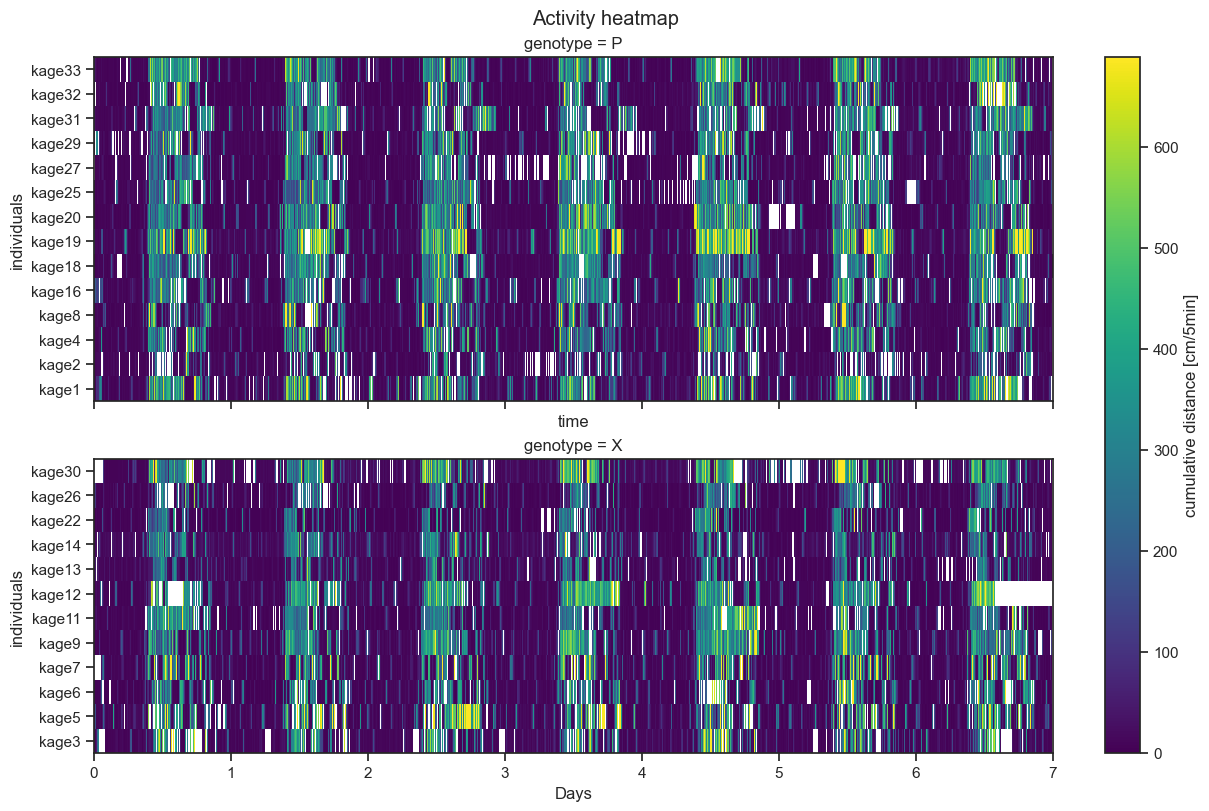

In [11]:
plot_activity_heatmap(
    activity,
    save_path=best_week_dir / "activity_heatmap.png",
    cmap="viridis",
    group_by=GROUPS_VAR,
)

## Generate and plot actograms

We now reshape the activity data into a 3D `actogram` array with dimensions `(individuals, day, minutes)`. For each individual, each row represents one day, and each column represents a bin within that day. The coordinate assigned to each bin corresponds to the center of the time bin. There is also a boolean non-dimension coordinate named `dark` that indicates whether each time bin is in the dark phase. This format allows us to visualize daily activity patterns aligned by time of day.

In [12]:
# Get days, excluding the last one (just midnight of the next day)
daily_groups = list(activity.groupby("time.date"))[:-1]
n_days = len(daily_groups)

# Create an empty actogram of shape (individuals n_days, n_daily_bins)
actogram = xr.DataArray(
    np.full((ds.sizes["individuals"], n_days, n_daily_bins), np.nan),
    dims=["individuals", "day", "minutes"],
    coords={
        "individuals": ds.individuals,
        "day": np.arange(1, n_days + 1),
        "minutes": bin_centers,
    },
)
# Also attach the genotype coordinate to the actogram
actogram = actogram.assign_coords(**{GROUPS_VAR: ("individuals", group_labels)})

# Fill in the actogram with daily activity data
for kage in tqdm(ds.individuals.values, total=ds.sizes["individuals"]):
    for i, (_, day_activity) in enumerate(daily_groups):
        actogram.loc[dict(individuals=kage, day=i + 1)] = day_activity.sel(
            individuals=kage
        ).values

# Copy attributes from activity to actogram
actogram.attrs = activity.attrs.copy()

# Determine vmax for actogram color scaling based on the 99th % of values
# (Used across subsequent heatmaps to make them comparable)
vmax = activity.quantile(0.99).item()

actogram

100%|██████████| 26/26 [00:00<00:00, 176.92it/s]


<xarray.DataArray (individuals: 26, day: 7, minutes: 288)> Size: 419kB
12.58 9.943 13.28 10.52 31.36 89.07 50.94 ... 72.72 47.04 43.0 13.21 15.04 10.61
Coordinates:
  * individuals  (individuals) <U6 624B 'kage1' 'kage2' ... 'kage32' 'kage33'
    genotype     (individuals) <U1 104B 'P' 'P' 'X' 'P' 'X' ... 'X' 'P' 'P' 'P'
  * day          (day) int64 56B 1 2 3 4 5 6 7
  * minutes      (minutes) float64 2kB 2.5 7.5 12.5 ... 1.432e+03 1.438e+03
Attributes: (5)

Next, we plot **individual actograms** for each kage. Each actogram shows activity (distance travelled) as a function of time of day (x-axis) and day number (y-axis). A bar at the top indicates the light/dark cycle, with the dark period shown in black.

100%|██████████| 26/26 [00:03<00:00,  7.13it/s]


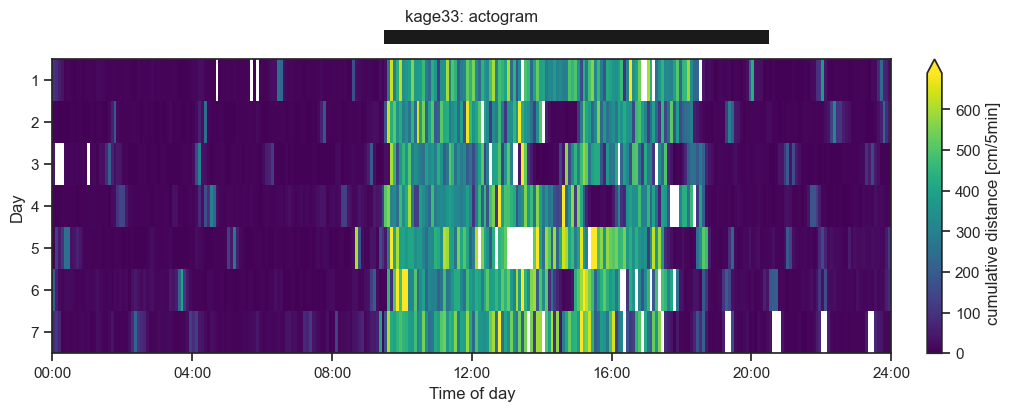

In [13]:
for kage in tqdm(ds.individuals.values, total=ds.sizes["individuals"]):
    fig = plot_actogram(
        actogram.sel(individuals=kage),
        dark_period=DARK_PERIOD,
        title=f"{kage}: actogram",
        save_path=best_week_dir / kage / f"{kage}_actogram.png",
        vmax=vmax,
    )
    if kage != ds.individuals.values[-1]:
        plt.close(fig)

Let's stack all individuals and days of this cohortinto a single tall 2D array to visualise the full cohort at a glance.

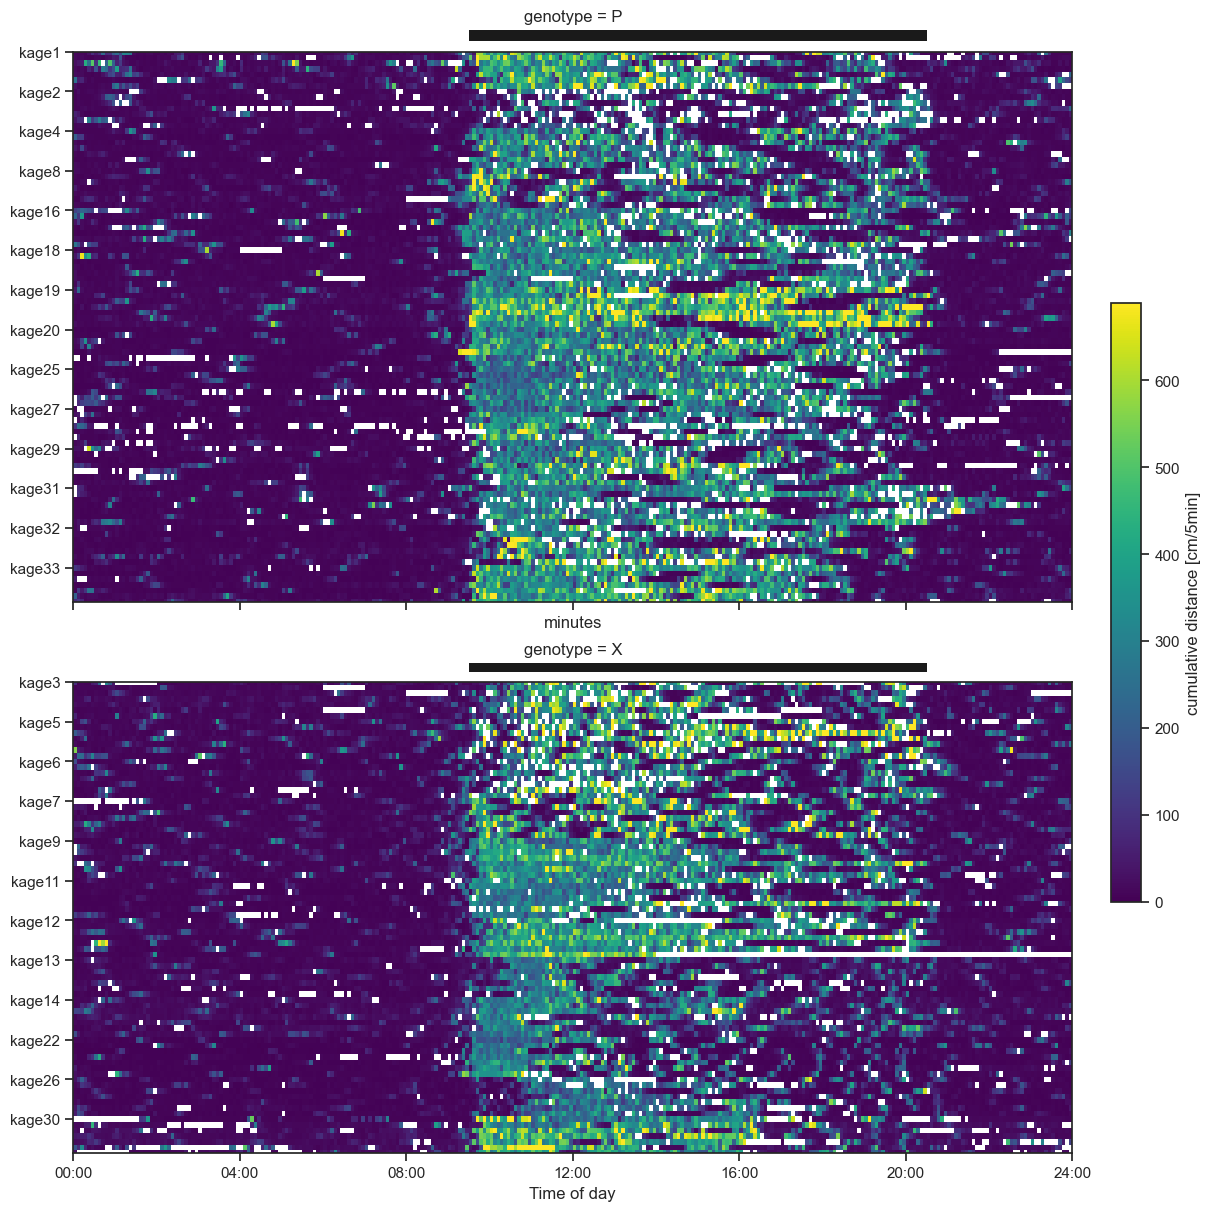

In [14]:
_ = plot_actogram_cohort(
    actogram,
    dark_period=DARK_PERIOD,
    save_path=best_week_dir / "actogram_cohort.png",
    vmax=vmax,
    group_by=GROUPS_VAR,
)

## Average daily activity profile

Average the actogram over days to get a single representative daily activity profile per individual. This is a useful first look at the circadian pattern — consistent peaks during the dark period indicate normal nocturnal activity.

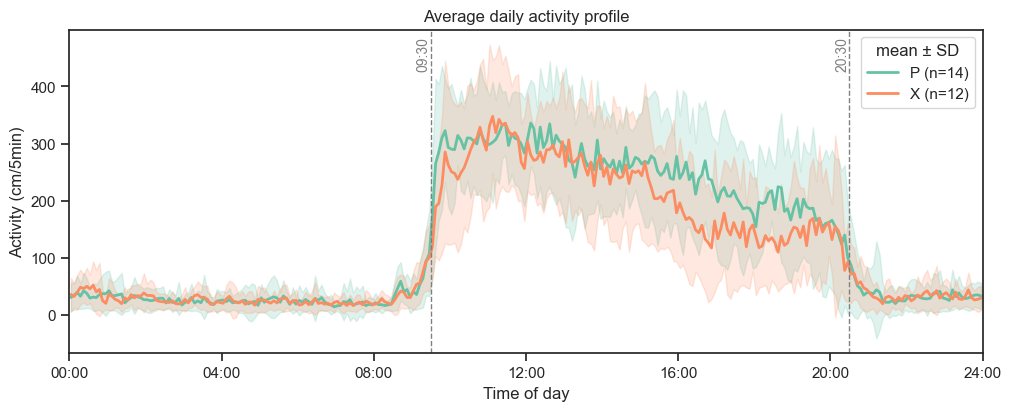

In [15]:
_ = plot_mean_daily_activity_profile(
    actogram,
    dark_period=DARK_PERIOD,
    save_path=best_week_dir / "mean_daily_activity_profile.png",
    group_by=GROUPS_VAR,
)

## Save activity and actograms

Finally, let's save the activity and actogram arrays to disk for future reference.
We combine both the `activity` time series and the `actogram` into a single `xarray.Dataset`, preserving the relevant attributes for context.

In [16]:
ds_activity = xr.Dataset(
    {"activity": activity, "actogram": actogram},
    attrs=activity.attrs,
)

ds_activity.to_netcdf(best_week_dir / "activity_best_week.nc")

In [51]:
ds_activity.close()